# Customer Churn Prediction

## Aim

The aim of this project is to build a machine learning model that can predict whether a customer is likely to churn. 

Churn means that a customer leaves the company or stops using the service. This is an important problem because retaining customers is usually cheaper than trying to acquire new ones.

In this notebook, I go through the full machine learning workflow. I first inspect and clean the data, then explore patterns in churn behaviour, prepare the data for modelling, train classification models, and finally compare their performance.

The main goal is not just to build a model, but also to understand which factors are linked to customer churn.

In [9]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning tools
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

## Importing and Inspecting the Dataset

The first step is to load the dataset and inspect its basic structure. This gives a general sense of the data and highlights any potential issues.

In [10]:
# Load dataset
churn_df = pd.read_csv("Telco-Customer-Churn.csv")

# Preview data
print(churn_df.head())

# Check dimensions
print("Shape of dataset:", churn_df.shape)

# Check data types and structure
print(churn_df.info())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

## Data Cleaning

The TotalCharges column is stored as text due to blank values. This needs to be converted into numeric format.

Rows with missing values are removed, and the customerID column is dropped as it is not useful for prediction.

The target variable is converted into binary format.

In [14]:
# Check missing values
print(churn_df.isnull().sum())

# Convert TotalCharges to numeric (invalid values become NaN)
churn_df["TotalCharges"] = pd.to_numeric(churn_df["TotalCharges"], errors="coerce")

# Check missing values created
print(churn_df["TotalCharges"].isnull().sum())

# Drop rows with missing TotalCharges
churn_df = churn_df.dropna(subset=["TotalCharges"])

# Remove ID column
churn_df = churn_df.drop("customerID", axis=1)

# Convert target variable
churn_df["Churn"] = churn_df["Churn"].map({"Yes": 1, "No": 0})

print(churn_df.head())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
11
   gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  Female              0     Yes         No       1           No   
1    Male              0      No         No      34          Yes   
2    Male              0      No         No       2          Yes   
3    Male              0      No         No      45           No   
4  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  \
0  No phone service             DSL           

## Exploring the Target Variable

There are 5,163 non-churners and 1,869 churners. This means around 73.4% of customers stayed, while 26.6% left.

The countplot clearly shows this imbalance, with the non-churn bar much higher.

This means accuracy alone is not enough, and metrics such as recall and ROC-AUC are important.

0    5163
1    1869
Name: Churn, dtype: int64
0    0.734215
1    0.265785
Name: Churn, dtype: float64


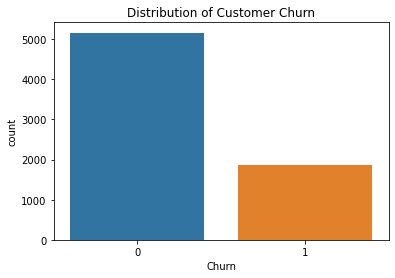

In [16]:
# Check distribution
print(churn_df["Churn"].value_counts())
print(churn_df["Churn"].value_counts(normalize=True))

# Plot distribution
sns.countplot(x="Churn", data=churn_df)
plt.title("Distribution of Customer Churn")
plt.show()

## Exploratory Data Analysis

The goal is to identify patterns linked to churn.

### Contract Type

The chart shows that customers on month-to-month contracts have the highest churn rate by a large margin.

The bar for month-to-month is significantly higher than for one-year and two-year contracts.

This suggests that customers with less commitment are much more likely to leave.

### Internet Service

Customers with fiber optic service show the highest churn rate.

The bar for fiber optic is clearly higher than DSL and no internet service.

This may suggest that these customers are more price-sensitive or have higher expectations.

### Monthly Charges

The boxplot shows that customers who churn tend to have higher monthly charges.

The median monthly charge is visibly higher for churners, although there is some overlap.

### Tenure

The tenure boxplot shows one of the strongest patterns.

Customers who churn have much lower tenure on average, while long-term customers are far less likely to churn.

This suggests churn risk is highest early in the customer lifecycle.

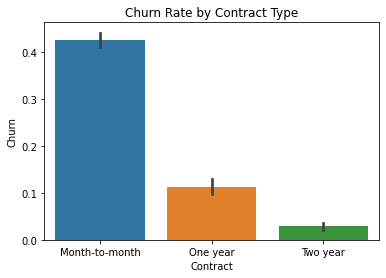

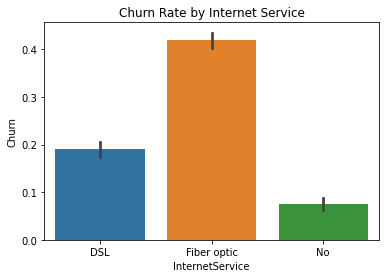

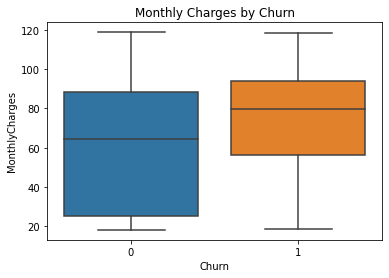

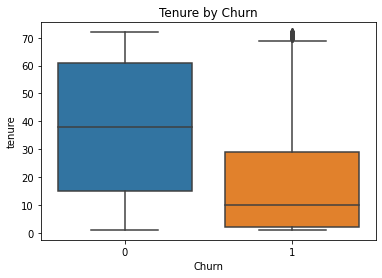

In [21]:
# Contract vs churn
sns.barplot(x="Contract", y="Churn", data=churn_df)
plt.title("Churn Rate by Contract Type")
plt.show()

# Internet service vs churn
sns.barplot(x="InternetService", y="Churn", data=churn_df)
plt.title("Churn Rate by Internet Service")
plt.show()

# Monthly charges vs churn
sns.boxplot(x="Churn", y="MonthlyCharges", data=churn_df)
plt.title("Monthly Charges by Churn")
plt.show()

# Tenure vs churn
sns.boxplot(x="Churn", y="tenure", data=churn_df)
plt.title("Tenure by Churn")
plt.show()

## Preparing the Data for Modelling

The next step is to separate the predictors from the target variable and split the data into training and test sets.

I also identify which variables are numeric and which are categorical, because they need different preprocessing steps.

Numeric variables are scaled, while categorical variables are converted using one-hot encoding.

In [33]:
# Separate features and target
X = churn_df.drop("Churn", axis=1)
y = churn_df["Churn"]

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Identify numeric and categorical columns
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric columns:", numeric_features)
print("Categorical columns:", categorical_features)

Numeric columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [35]:
# Preprocessing for numeric columns
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

# Preprocessing for categorical columns
categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

## Model Selection

For this project, I use two classification models.

### Logistic Regression

Logistic Regression is a good baseline model because it is simple, quick to train, and easy to interpret.

### Random Forest

Random Forest is a more flexible tree-based model that can capture more complex relationships in the data.

Using both models makes it possible to compare a simple interpretable approach with a more flexible one.

In [40]:
# Define Logistic Regression pipeline
log_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

# Define Random Forest pipeline
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=200, random_state=42))
])

# Train both models
log_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('classifier',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

## Model Evaluation

To evaluate the models properly, I use several metrics rather than just accuracy.

Accuracy can be misleading when one class is more common than the other.

Precision shows how many predicted churn cases were correct.

Recall shows how many of the true churn cases were identified.

F1-score gives a balance between precision and recall.

ROC-AUC measures how well the model separates churners from non-churners overall.

Recall is especially important here because the business goal is often to identify customers at risk of leaving.

## Model Evaluation Results

Logistic Regression results:
- Accuracy: 0.805
- Precision: 0.650
- Recall: 0.575
- F1-score: 0.610
- ROC-AUC: 0.836

Random Forest results:
- Accuracy: 0.790
- Precision: 0.634
- Recall: 0.492
- F1-score: 0.554
- ROC-AUC: 0.814

Logistic Regression performs better across all key metrics.

It achieves higher recall, meaning it identifies more churners.

From the confusion matrix:
- Logistic Regression correctly identifies 215 churners and misses 159
- Random Forest correctly identifies 184 and misses 190

This shows Logistic Regression is better at detecting churn.

The higher ROC-AUC (0.836 vs 0.814) also shows better overall model performance.

In [47]:
# Model evaluation function
def evaluate_model(y_true, y_pred, y_prob, model_name):
    print(model_name)
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1:", f1_score(y_true, y_pred))
    print("ROC-AUC:", roc_auc_score(y_true, y_prob))
    print(confusion_matrix(y_true, y_pred))
    print()

# Predictions
log_preds = log_model.predict(X_test)
log_probs = log_model.predict_proba(X_test)[:, 1]

rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

# Evaluate
evaluate_model(y_test, log_preds, log_probs, "Logistic Regression")
evaluate_model(y_test, rf_preds, rf_probs, "Random Forest")

Logistic Regression
Accuracy: 0.8045486851457001
Precision: 0.649546827794562
Recall: 0.5748663101604278
F1: 0.6099290780141843
ROC-AUC: 0.8358772797158995
[[917 116]
 [159 215]]

Random Forest
Accuracy: 0.7896233120113717
Precision: 0.6344827586206897
Recall: 0.4919786096256685
F1: 0.5542168674698795
ROC-AUC: 0.8139989957084653
[[927 106]
 [190 184]]



## Interpreting the Drivers of Churn

After comparing the models, the next step is to understand which variables are most strongly associated with churn.

For Logistic Regression, the model coefficients show whether a variable increases or decreases churn risk.

For Random Forest, feature importances show which variables the model relied on most when making predictions.

In [54]:
# Get transformed feature names
feature_names = log_model.named_steps["preprocessor"].get_feature_names_out()

# Get Logistic Regression coefficients
log_coefficients = log_model.named_steps["classifier"].coef_[0]

# Put coefficients into a dataframe
log_coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": log_coefficients
})

# Rank by absolute size
log_coef_df["AbsoluteCoefficient"] = log_coef_df["Coefficient"].abs()
log_coef_df = log_coef_df.sort_values(by="AbsoluteCoefficient", ascending=False)

print("Top Logistic Regression features:")
print(log_coef_df[["Feature", "Coefficient"]].head(10))

# Get Random Forest feature importances
rf_importance = rf_model.named_steps["classifier"].feature_importances_

# Put feature importances into a dataframe
rf_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_importance
}).sort_values(by="Importance", ascending=False)

print("Top Random Forest features:")
print(rf_importance_df.head(10))

Top Logistic Regression features:
                             Feature  Coefficient
1                        num__tenure    -1.349816
36      cat__Contract_Month-to-month     0.719375
16  cat__InternetService_Fiber optic     0.703220
38            cat__Contract_Two year    -0.670445
3                  num__TotalCharges     0.641335
2                num__MonthlyCharges    -0.559429
15          cat__InternetService_DSL    -0.515411
32              cat__StreamingTV_Yes     0.301363
35          cat__StreamingMovies_Yes     0.287426
18            cat__OnlineSecurity_No     0.269941
Top Random Forest features:
                                Feature  Importance
3                     num__TotalCharges    0.158200
1                           num__tenure    0.142352
2                   num__MonthlyCharges    0.136054
36         cat__Contract_Month-to-month    0.053717
18               cat__OnlineSecurity_No    0.031239
43  cat__PaymentMethod_Electronic check    0.029722
16     cat__InternetServ

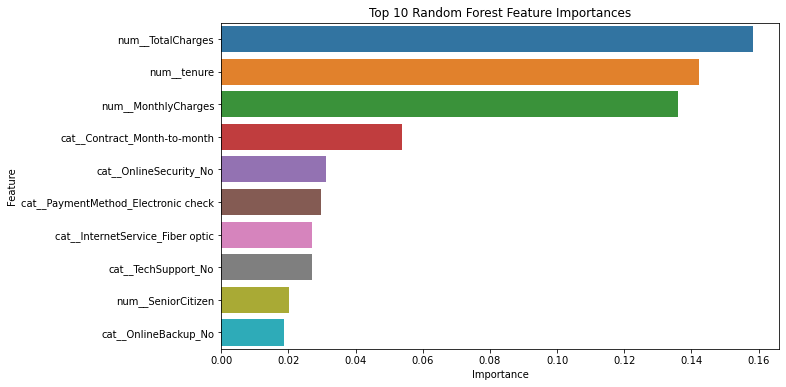

In [55]:
# Plot top 10 Random Forest feature importances
plt.figure(figsize=(10, 6))
sns.barplot(data=rf_importance_df.head(10), x="Importance", y="Feature")
plt.title("Top 10 Random Forest Feature Importances")
plt.show()

## What the Feature Results Show

The feature results are broadly consistent with the earlier EDA.

In the Logistic Regression model, tenure is the strongest feature by absolute coefficient, with a value of about -1.35. This suggests that longer-tenure customers are much less likely to churn.

Contract_Month-to-month has a strong positive coefficient of about 0.72, indicating that customers on month-to-month contracts are much more likely to churn.

Contract_Two year has a negative coefficient of about -0.67, showing that longer contracts reduce churn risk.

InternetService_Fiber optic also has a strong positive coefficient of about 0.70, suggesting that fiber optic customers are more likely to churn than the reference group.

In the Random Forest model, the most important features are TotalCharges, tenure, and MonthlyCharges. Contract_Month-to-month, OnlineSecurity_No, PaymentMethod_Electronic check, and InternetService_Fiber optic also appear among the most important variables.

Overall, the results suggest that customers are more likely to churn when they:
- have shorter tenure
- are on month-to-month contracts
- have fiber optic service
- pay higher monthly charges
- lack services such as online security or tech support

These findings are useful because they are statistically meaningful and also make intuitive business sense.

This project shows a full machine learning workflow for predicting customer churn.

The analysis suggests that contract type, tenure, monthly charges, and internet service are important drivers of churn.

In particular, shorter-tenure customers and customers on month-to-month contracts appear much more likely to leave.

Logistic Regression performs slightly better than Random Forest across all key metrics, including accuracy, recall, F1-score, and ROC-AUC.

Since it also offers clearer interpretability, Logistic Regression appears to be the better model for this project.

From a business point of view, this analysis could help a company identify customers who are at greater risk of leaving and target them with retention strategies.

A natural next step would be to tune the models further, test additional algorithms, or adjust the classification threshold depending on whether the business values recall, precision, or a balance of both.